In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Read the dataset
df = pd.read_csv("C:/Users/Rishabh/Downloads/Clean_Python_Project 1.csv")

In [ ]:
# Data_ cleaning
df_clean = df.dropna(subset=["Indicator", "Clean_Value", "Subgroup"]).copy()

# Fill missing CI values with median
df_clean.loc[:, "Low CI"] = df_clean["Low CI"].fillna(df_clean["Low CI"].median())
df_clean.loc[:, "High CI"] = df_clean["High CI"].fillna(df_clean["High CI"].median())

# Add confidence interval width
df_clean.loc[:, "CI Width"] = df_clean["High CI"] - df_clean["Low CI"]

# Converting time columns to datetime
df_clean.loc[:, "Time Period Start Date"] = pd.to_datetime(df_clean["Time Period Start Date"], errors='coerce')
df_clean.loc[:, "Time Period End Date"] = pd.to_datetime(df_clean["Time Period End Date"], errors='coerce')

# Strip whitespace from string columns only (excluding datetime/numeric)
string_cols = [col for col in df_clean.columns if df_clean[col].dtype == 'object']
for col in string_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Ensure quartile range is string for consistency
if "Clean Quartile Range" in df_clean.columns:
    df_clean["Clean Quartile Range"] = df_clean["Clean Quartile Range"].astype(str)

# Clean column names if needed
df_clean.columns = [col.strip() for col in df_clean.columns]

In [ ]:
# Objective 1: Compare prevalence across subgroups for the top 5 subgroups
def analyze_top5_subgroups():
    subgroup_means = df_clean.groupby("Subgroup")["Clean_Value"].mean().sort_values(ascending=False)
    top5_subgroups = subgroup_means.head(5).index.tolist()
    df_top5 = df_clean[df_clean["Subgroup"].isin(top5_subgroups)]

    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_top5, x="Subgroup", y="Clean_Value", hue="Indicator", errorbar='sd')
    plt.title("Top 5 Subgroups by Average Mental Health Symptom Value")
    plt.ylabel("Average Reported Symptom Value (%)")
    plt.xlabel("Subgroup")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Call the function
analyze_top5_subgroups()

In [ ]:
# Objective 2: Track mental health trends over time
def analyze_trends_over_time():
    df_sorted = df_clean.sort_values(by='Time Period Start Date')
    plt.figure(figsize=(14, 6))
    sns.lineplot(data=df_sorted, x='Time Period Start Date', y='Clean_Value', hue='Indicator')
    plt.title('Mental Health Trends Over Time')
    plt.ylabel('Reported Symptom Value (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
# Objective 3: State-level analysis of mental health indicators
def analyze_by_state():
    state_means = df_clean.groupby("State")["Clean_Value"].mean().sort_values(ascending=False)
    plt.figure(figsize=(14, 8))
    state_means.plot(kind='bar')
    plt.title("Average Mental Health Symptom Values by State")
    plt.ylabel("Average Symptom Value (%)")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

In [ ]:
# Objective 4: Assess statistical reliability using confidence intervals
def assess_confidence_intervals():
    plt.figure(figsize=(14, 6))
    sns.histplot(df_clean['CI Width'], bins=30, kde=True)
    plt.title('Distribution of Confidence Interval Widths')
    plt.xlabel('Confidence Interval Width')
    plt.tight_layout()
    plt.show()

In [ ]:
# Objective 5: Quartile analysis of mental health indicators
def quartile_analysis():
    df_q = df_clean[df_clean["Clean Quartile Range"].notna()].copy()
    df_q["Clean Quartile Range"] = df_q["Clean Quartile Range"].astype(str)
    # Determine sorted order: try to sort by lower bound of the range if possible
    try:
        order = sorted(df_q["Clean Quartile Range"].unique(), key=lambda x: float(x.split(" - ")[0]) if " - " in x else float('inf'))
    except Exception as e:
        order = df_q["Clean Quartile Range"].unique()
        
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df_q, x='Clean Quartile Range', order=order)
    plt.title("Frequency of Quartile Ranges for Mental Health Symptoms")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
# Objective 6: Study the impact of pandemic response phases on mental health
def analyze_by_phase():
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_clean, x='Phase', y='Clean_Value', hue='Indicator')
    plt.title('Mental Health Values by Pandemic Response Phase')
    plt.ylabel('Reported Symptom Value (%)')
    plt.tight_layout()
    plt.show()

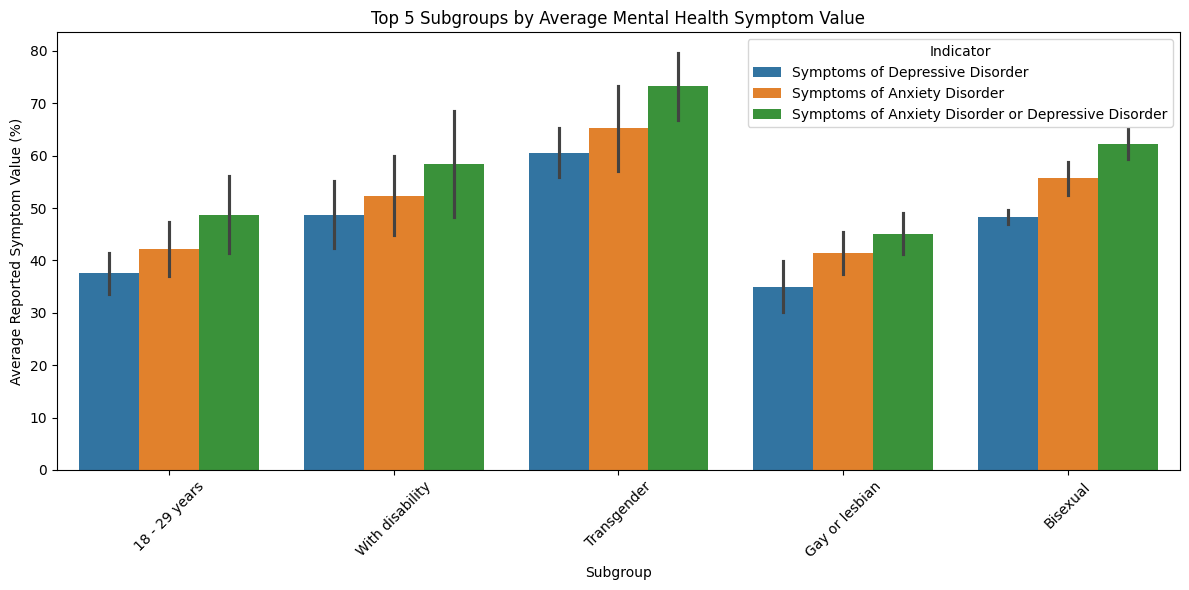

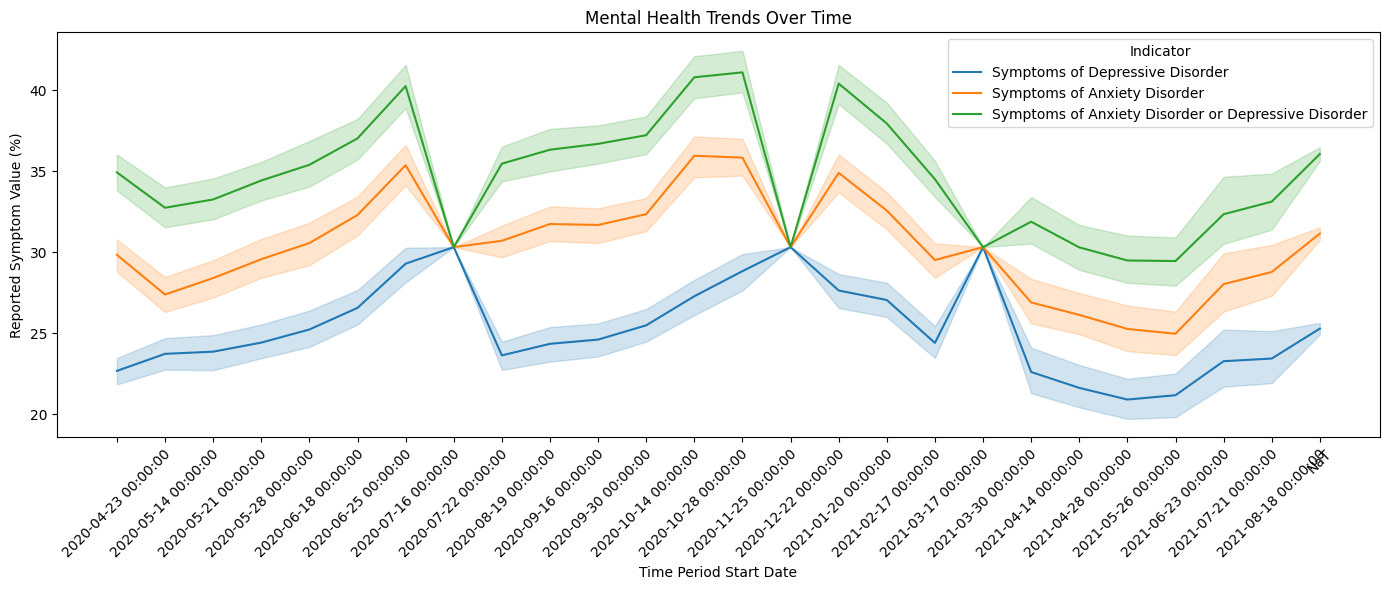

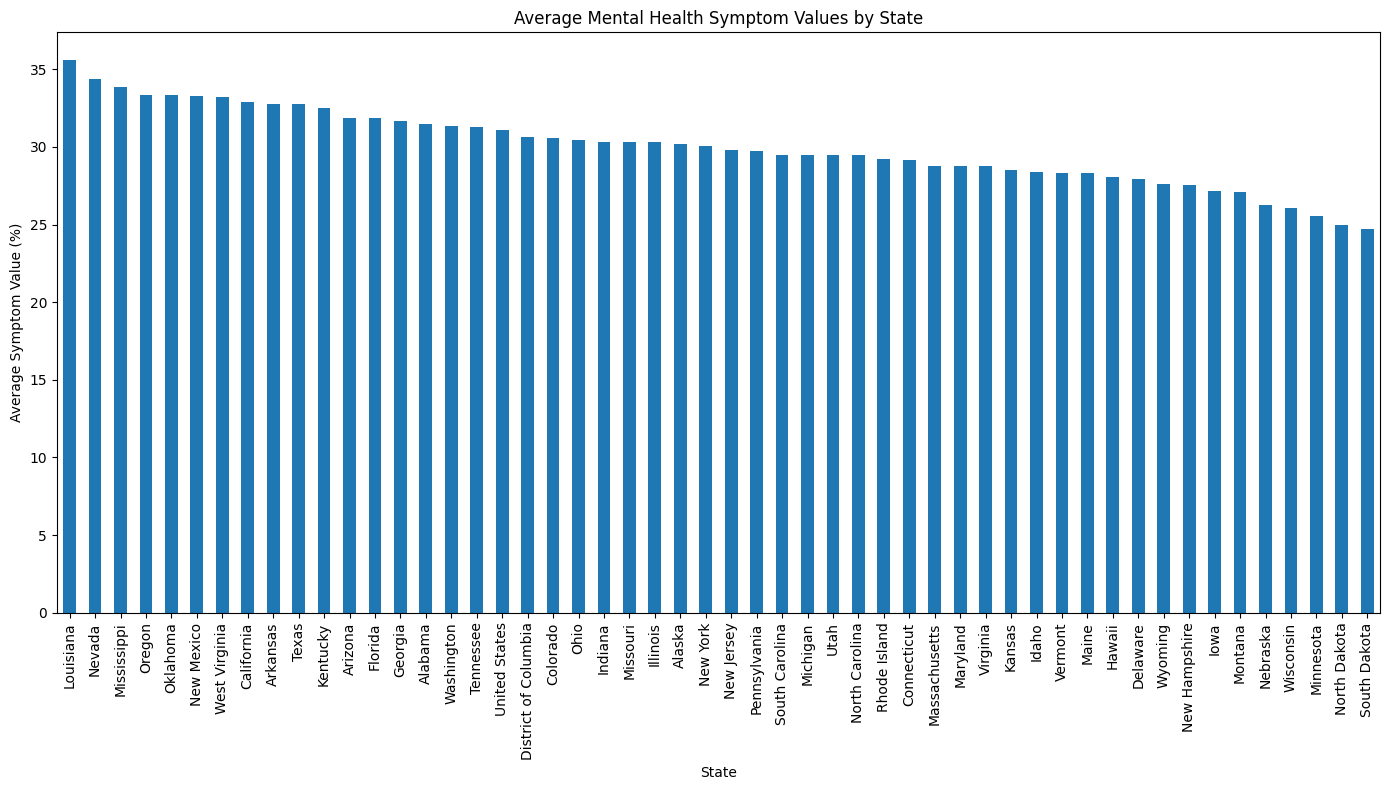

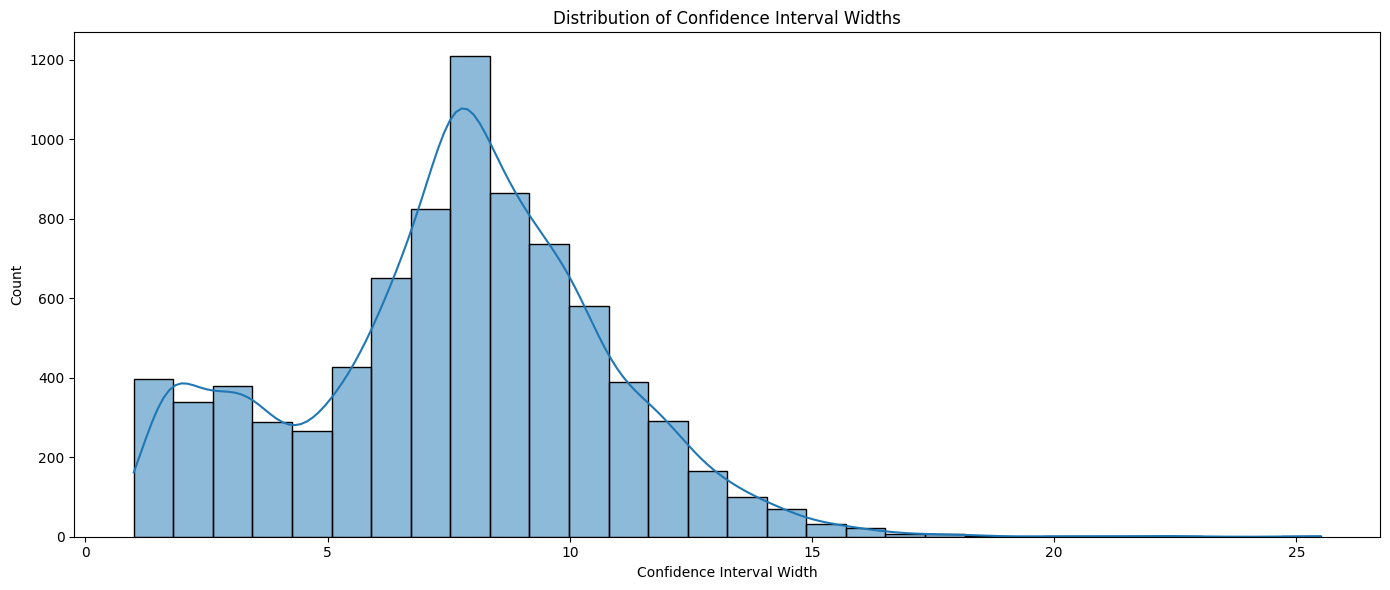

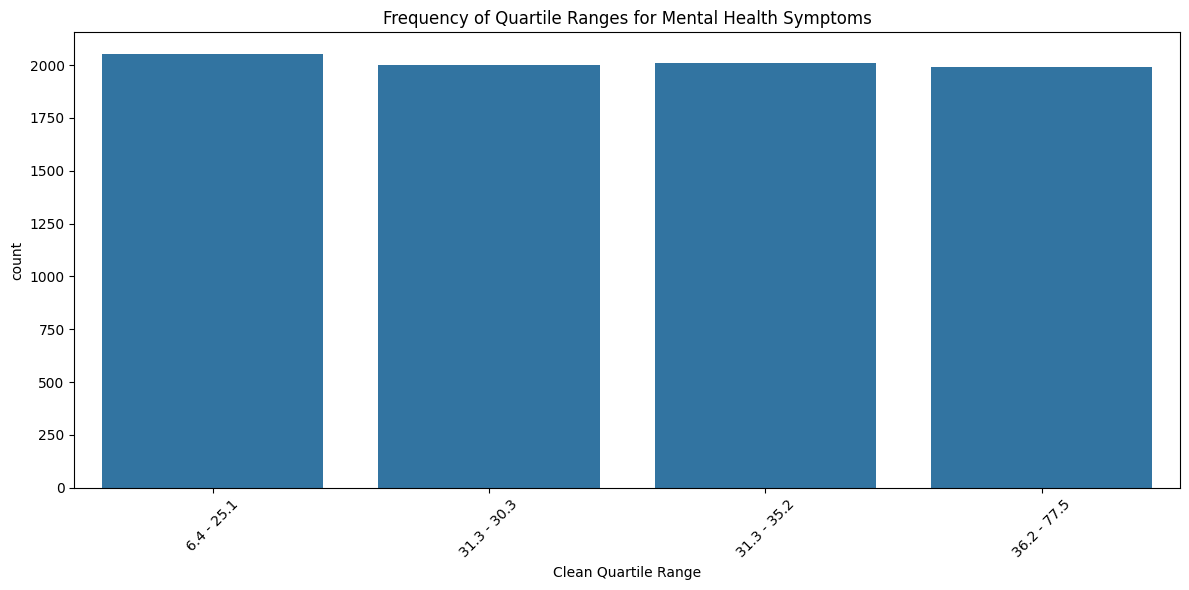

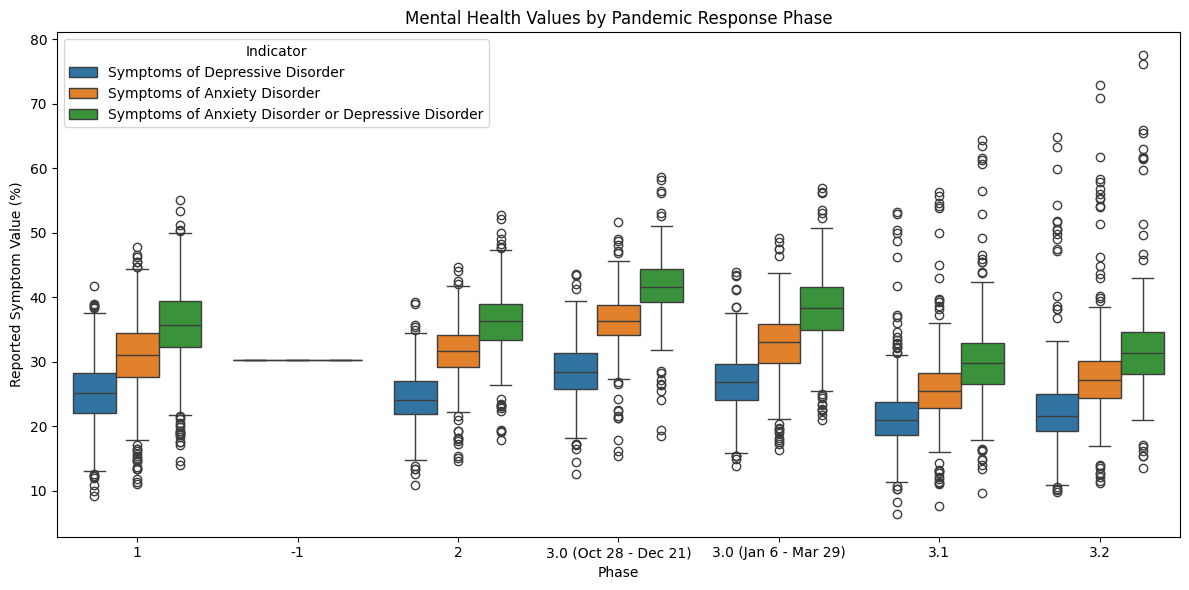

In [12]:
# 3. RUN ALL ANALYSIS
analyze_top5_subgroups()
analyze_trends_over_time()
analyze_by_state()
assess_confidence_intervals()
quartile_analysis()
analyze_by_phase()